# No-Optimization CG-Projection Enclosure for the Updated Plate System

This notebook applies the supplied fixed-iteration CG-projection algorithm to the already-symmetrized system in `system_updated_plate`. It uses symmetric Jacobi scaling, records exactly $m=500$ CG directions, selects a numerically independent stable subset, and evaluates the Gram-corrected projector.

There is no relaxation term: the projected radius is exactly

$$
d_m^{\mathrm{proj}} = |\Pi_m|d^0.
$$

The plate matrix has 21,570 coordinates. The final hull is computed for all coordinates by forming exact projector rows in memory-bounded blocks; only the intermediate diagnostic checkpoints are restricted to 80 evenly sampled rows. Both supplied initial boxes already contain the verified solution and are processed without expansion.


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation
from scipy.sparse import diags, load_npz
from scipy.sparse.linalg import cg


data_dir = Path("system_updated_plate")
A = load_npz(data_dir / "A.npz").tocsr()
b = np.loadtxt(data_dir / "b.dat", dtype=float)
x_star = np.loadtxt(data_dir / "soln_x.dat", dtype=float)
boxes = {
    "box_1": np.loadtxt(data_dir / "box_1.dat", dtype=float),
    "box_2": np.loadtxt(data_dir / "box_2.dat", dtype=float),
}

n = len(b)
if A.shape != (n, n):
    raise ValueError(f"Expected A to have shape {(n, n)}, got {A.shape}.")
if x_star.shape != (n,):
    raise ValueError(f"Expected x_star to have shape {(n,)}, got {x_star.shape}.")
for box_name, box in boxes.items():
    if box.shape != (n, 2):
        raise ValueError(f"{box_name} should have shape {(n, 2)}, got {box.shape}.")
    if np.any(box[:, 0] > box[:, 1]):
        raise ValueError(f"{box_name} has lower bounds above upper bounds.")
    if not np.all((box[:, 0] <= x_star) & (x_star <= box[:, 1])):
        raise ValueError(f"{box_name} does not contain the stored solution.")
    if np.any(np.isclose(np.mean(box, axis=1), x_star, rtol=0.0, atol=1e-15)):
        raise ValueError(f"{box_name} is centered on the solution in a coordinate.")
    if np.ptp(box[:, 1] - box[:, 0]) == 0.0:
        raise ValueError(f"{box_name} does not have coordinate-varying diameters.")

solution_residual = np.linalg.norm(b - A @ x_star)
print(f"system dimension: {n}")
print(f"matrix nonzeros: {A.nnz}")
print(f"stored solution residual: {solution_residual:.6e}")


system dimension: 21570
matrix nonzeros: 659988
stored solution residual: 5.011750e-11


## Jacobi scaling

With `scale = sqrt(diag(A))`, solve in the coordinates $y=\mathrm{scale}\,x$ and transform the reported enclosure coordinates back to the original variables.

The updated dataset already stores a verified solution of the symmetric system and two coordinate-varying, off-center boxes that contain it. Consequently, no coordinate-wise box expansion is applied here.


In [2]:
diagonal = A.diagonal()
if np.any(diagonal <= 0):
    raise ValueError("Jacobi scaling requires a positive diagonal.")

scale = np.sqrt(diagonal)
inverse_scale = 1.0 / scale
A_hat = diags(inverse_scale) @ A @ diags(inverse_scale)
b_hat = inverse_scale * b

cg_projection_iterations = 500
diagnostic_period = 50
projection_qr_tolerance = 1e-10
projection_max_gram_condition = 1e12
projector_row_block_size = 128
max_tracked_coordinates = 80

all_coordinates = np.arange(n)
if n <= max_tracked_coordinates:
    tracked_indices = all_coordinates
else:
    tracked_positions = np.linspace(0, n - 1, max_tracked_coordinates).round().astype(int)
    tracked_indices = np.unique(tracked_positions)

print(f"tracked diagnostic coordinates: {len(tracked_indices)}")
print(f"fixed CG iterations m: {cg_projection_iterations}")
print(f"diagnostic period: {diagnostic_period}")


tracked diagnostic coordinates: 80
fixed CG iterations m: 500
diagnostic period: 50


## Exact fixed-iteration CG-projection enclosure

The implementation below follows the supplied algorithm directly. It records exactly $m$ CG search directions from the initial box center, selects a numerically independent subset, forms $G_m=P_m^T\hat A P_m$, and uses linear solves with $G_m$ in both $\widehat x_m$ and $\Pi_m$.

Column normalization is used only as an algebraically invariant change of basis for stable computation: rescaling selected columns does not change $P_m(P_m^T\hat A P_m)^{-1}P_m^T$. No identity-Gram or exact-conjugacy shortcut is used.

The exact hull radius is $|\Pi_m|d^0$. To avoid storing the dense 21,570-by-21,570 projector, its rows are formed in blocks; every row is still evaluated for the final enclosure. Additional checkpoint calculations evaluate the same formula on 80 sampled rows for diagnostics only.


In [3]:
from system_updated_plate.cg_projection_enclosure import (
    fixed_iteration_cg_with_directions,
    project_enclosure_rows,
    run_exact_cg_projection_enclosure,
    select_independent_directions,
)


## Run the enclosure

box_1: projector rows 2048/21570 (7.0 s)


box_1: projector rows 4096/21570 (13.7 s)


box_1: projector rows 6144/21570 (20.5 s)


box_1: projector rows 8192/21570 (27.4 s)


box_1: projector rows 10240/21570 (34.0 s)


...

box_2: projector rows 14336/21570 (48.7 s)


box_2: projector rows 16384/21570 (55.3 s)


box_2: projector rows 18432/21570 (62.3 s)


box_2: projector rows 20480/21570 (69.1 s)


box_2: projector rows 21570/21570 (73.1 s)
box_2 fixed CG iterations: 500
box_2 CG residual after m steps: 1.346366e-03
box_2 final QR rank: 476
box_2 final retained rank: 474
box_2 final cond(G): 1.628132e+11
box_2 max projected-center constraint residual: 1.179545e-12
box_2 final mean full-box shrinkage: 0.000000%
box_2 full coordinates tightened: 0 / 21570
box_2 final projected-radius ratio (min/median/max): 6.523e+00 / 2.297e+02 / 7.901e+04
box_2 raw projected intervals containing the original interval: 80 / 80
box_2 final full enclosure contains the stored solution: True


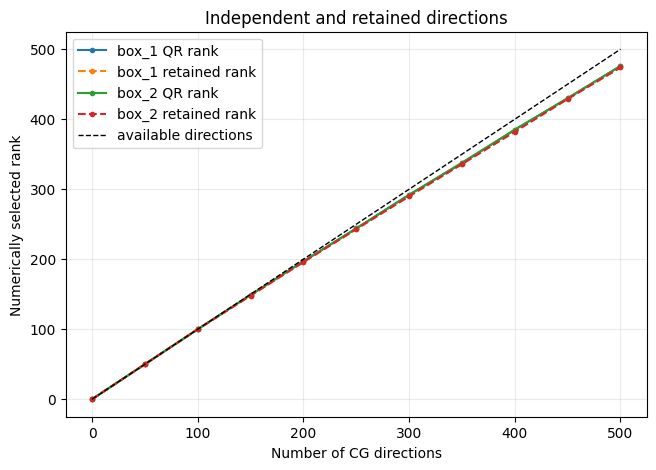

In [4]:
box_results = {}

for box_name, box in boxes.items():
    ell_hat = scale * box[:, 0]
    u_hat = scale * box[:, 1]

    result = run_exact_cg_projection_enclosure(
        A=A_hat,
        b=b_hat,
        lower=ell_hat,
        upper=u_hat,
        iterations=cg_projection_iterations,
        tracked_indices=tracked_indices,
        diagnostic_period=diagnostic_period,
        qr_tolerance=projection_qr_tolerance,
        max_gram_condition=projection_max_gram_condition,
        row_block_size=projector_row_block_size,
        progress_label=box_name,
    )

    result["box_name"] = box_name
    result["ell_x"] = result["ell"] / scale
    result["u_x"] = result["u"] / scale
    result["x_hat_x"] = result["x_hat"] / scale
    result["radius_x"] = result["radius"] / scale
    result["ell_history_x"] = result["ell_history"] / scale[tracked_indices][None, :]
    result["u_history_x"] = result["u_history"] / scale[tracked_indices][None, :]
    result["projected_center_history_x"] = (
        result["projected_center_history"] / scale[tracked_indices][None, :]
    )
    result["projected_radius_history_x"] = (
        result["projected_radius_history"] / scale[tracked_indices][None, :]
    )
    initial_center = np.mean(box[tracked_indices], axis=1)
    initial_width = box[tracked_indices, 1] - box[tracked_indices, 0]
    initial_radius = 0.5 * initial_width
    width_history = result["u_history_x"] - result["ell_history_x"]
    with np.errstate(divide="ignore", invalid="ignore"):
        result["shrinkage_history"] = np.clip(
            100.0 * (1.0 - width_history / initial_width[None, :]),
            0.0,
            100.0,
        )
        result["projected_radius_ratio_history"] = (
            result["projected_radius_history_x"] / initial_radius[None, :]
        )
        result["center_shift_ratio_history"] = (
            np.abs(result["projected_center_history_x"] - initial_center[None, :])
            / initial_radius[None, :]
        )
        result["coverage_margin_ratio_history"] = (
            result["projected_radius_ratio_history"]
            - result["center_shift_ratio_history"]
        )

    final_ell = result["ell_x"]
    final_u = result["u_x"]
    result["full_contains_solution"] = bool(
        np.all((final_ell <= x_star) & (x_star <= final_u))
    )
    result["tracked_contains_solution"] = bool(
        np.all(
            (result["ell_history_x"][-1] <= x_star[tracked_indices])
            & (x_star[tracked_indices] <= result["u_history_x"][-1])
        )
    )
    result["qr_rank_history"] = np.r_[
        0, [diagnostic["qr_rank"] for diagnostic in result["diagnostics"]]
    ]
    result["retained_rank_history"] = np.r_[
        0, [diagnostic["retained_rank"] for diagnostic in result["diagnostics"]]
    ]
    result["gram_condition_history"] = np.r_[
        1.0, [diagnostic["gram_condition"] for diagnostic in result["diagnostics"]]
    ]
    result["gram_identity_fro_history"] = np.r_[
        0.0, [diagnostic["gram_identity_fro"] for diagnostic in result["diagnostics"]]
    ]
    result["gram_max_offdiag_history"] = np.r_[
        0.0, [diagnostic["gram_max_offdiag"] for diagnostic in result["diagnostics"]]
    ]
    box_results[box_name] = result

    full_initial_width = box[:, 1] - box[:, 0]
    full_final_width = result["u_x"] - result["ell_x"]
    full_shrinkage = np.clip(
        100.0 * (1.0 - full_final_width / full_initial_width), 0.0, 100.0
    )
    print(f"{box_name} fixed CG iterations: {len(result['residual_norms'])}")
    print(f"{box_name} CG residual after m steps: {result['residual_norms'][-1]:.6e}")
    print(f"{box_name} final QR rank: {result['qr_rank']}")
    print(f"{box_name} final retained rank: {result['retained_rank']}")
    print(f"{box_name} final cond(G): {result['gram_condition']:.6e}")
    print(f"{box_name} max projected-center constraint residual: {result['max_constraint_residual']:.6e}")
    print(
        f"{box_name} final mean full-box shrinkage: "
        f"{np.nanmean(full_shrinkage):.6f}%"
    )
    print(
        f"{box_name} full coordinates tightened: "
        f"{np.count_nonzero(full_shrinkage > 1e-10)} / {n}"
    )
    print(
        f"{box_name} final projected-radius ratio (min/median/max): "
        f"{np.min(result['projected_radius_ratio_history'][-1]):.3e} / "
        f"{np.median(result['projected_radius_ratio_history'][-1]):.3e} / "
        f"{np.max(result['projected_radius_ratio_history'][-1]):.3e}"
    )
    print(
        f"{box_name} raw projected intervals containing the original interval: "
        f"{np.count_nonzero(result['coverage_margin_ratio_history'][-1] >= 1.0)} / "
        f"{len(tracked_indices)}"
    )
    print(
        f"{box_name} final full enclosure contains the stored solution: "
        f"{result['full_contains_solution']}"
    )

max_direction_count = max(result["iterations"][-1] for result in box_results.values())
fig, ax = plt.subplots(figsize=(7.5, 5))
for box_name, result in box_results.items():
    ax.plot(
        result["iterations"],
        result["qr_rank_history"],
        marker="o",
        markersize=3,
        label=f"{box_name} QR rank",
    )
    ax.plot(
        result["iterations"],
        result["retained_rank_history"],
        marker="o",
        markersize=3,
        linestyle="--",
        label=f"{box_name} retained rank",
    )
ax.plot(
    [0, max_direction_count],
    [0, max_direction_count],
    color="black",
    linestyle="--",
    linewidth=1,
    label="available directions",
)
ax.set_xlabel("Number of CG directions")
ax.set_ylabel("Numerically selected rank")
ax.set_title("Independent and retained directions")
ax.grid(alpha=0.25)
ax.legend()
plt.show()


## Contraction diagnostics

These plots follow the performance-analysis ideas in the non-simplified `system_303_solver_v3.ipynb`: total width, incremental width reduction, fraction of coordinates tightened, coordinate-wise final bounds, Gram conditioning, and loss of $A$-conjugacy. The final enclosure is computed for every coordinate. Checkpoint histories use 80 evenly sampled rows to avoid repeating the expensive full-projector hull calculation at every diagnostic iteration.

The additional projected-radius diagnostic isolates the main obstruction. For an original interval with center $c_0$ and radius $d_0$, the raw projected interval contains the entire original interval whenever

$$
\frac{d_m^{\mathrm{proj}}-|x_m-c_0|}{d_0} \ge 1.
$$

In that case, intersecting the two intervals cannot contract that coordinate.

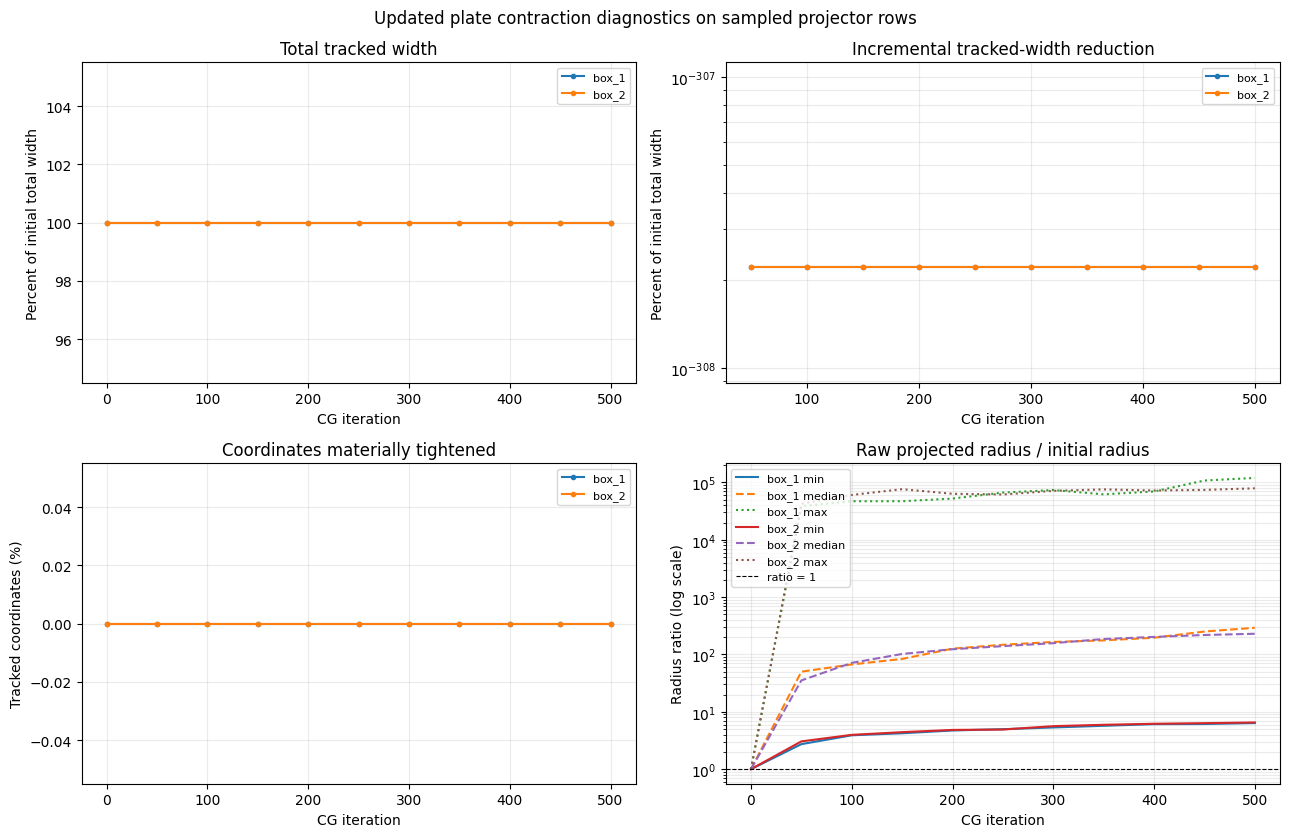

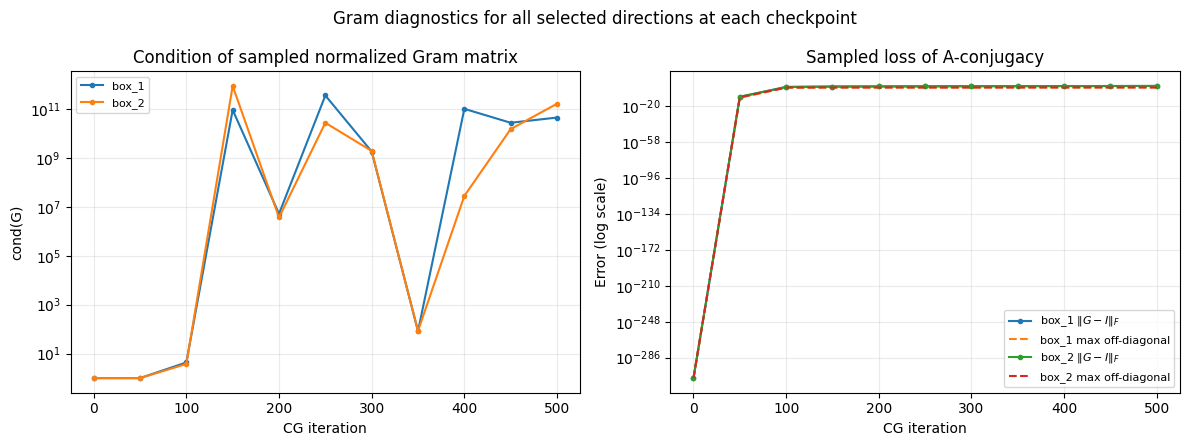

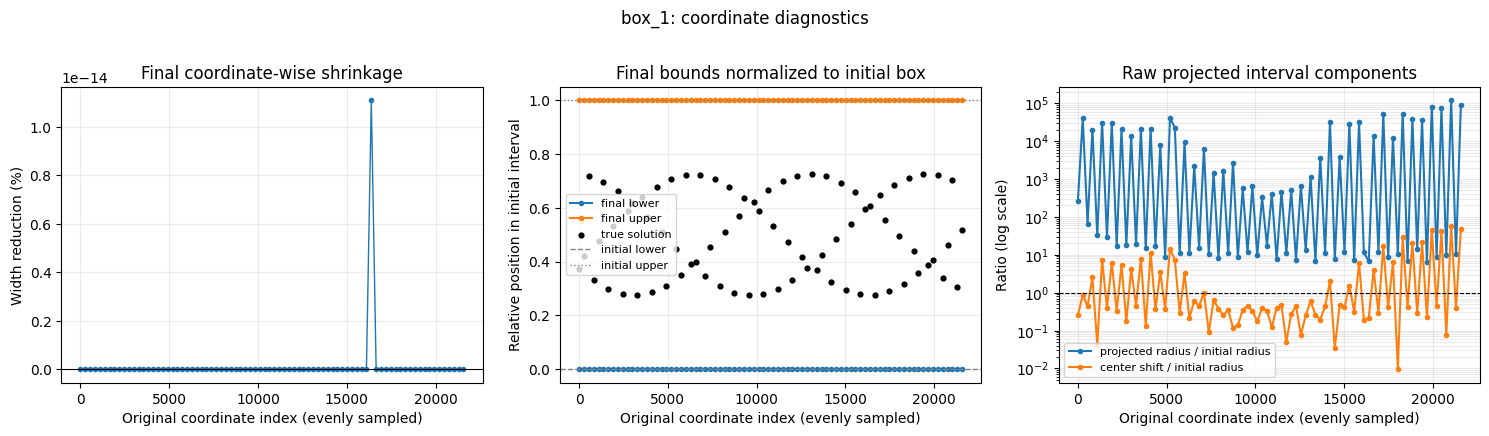

box_1 final diagnostic summary
  materially contracted coordinates: 0 / 80
  raw projected interval contains original: 80 / 80
  coverage-margin ratio min/median/max: 6.137e+00 / 2.919e+02 / 1.200e+05
  final cond(G): 4.430e+10
  final ||G-I||_F: 9.884e+00
  final max off-diagonal: 2.503e-01
  diagnosis: every sampled raw projected interval contains its original interval, so intersection cannot contract it.


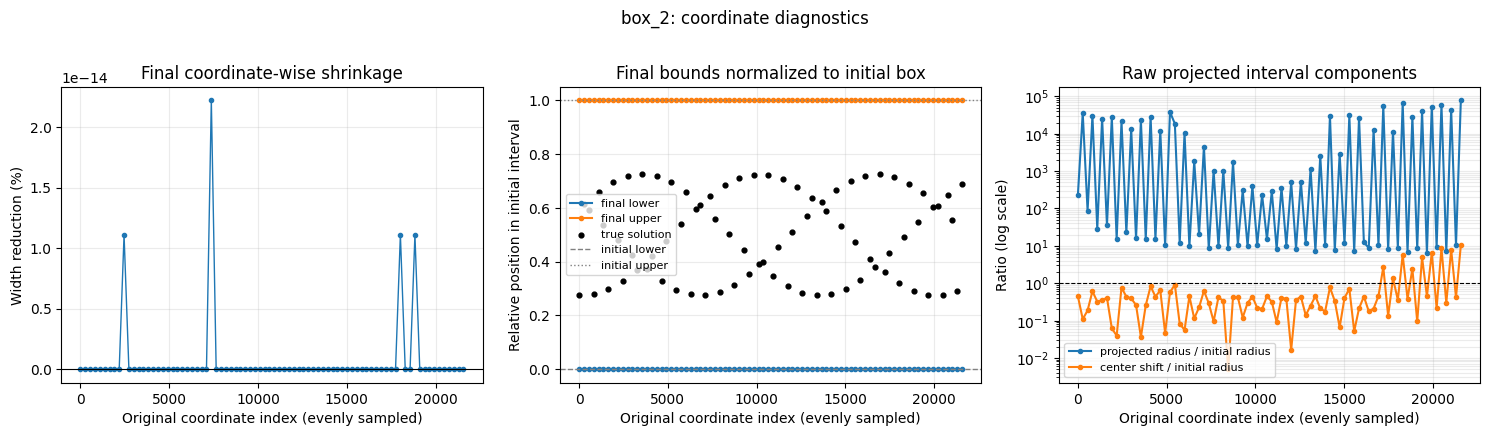

box_2 final diagnostic summary
  materially contracted coordinates: 0 / 80
  raw projected interval contains original: 80 / 80
  coverage-margin ratio min/median/max: 6.078e+00 / 2.294e+02 / 7.900e+04
  final cond(G): 1.628e+11
  final ||G-I||_F: 9.953e+00
  final max off-diagonal: 2.648e-01
  diagnosis: every sampled raw projected interval contains its original interval, so intersection cannot contract it.


In [5]:
diagnostic_series = {}

for box_name, result in box_results.items():
    box = boxes[box_name][tracked_indices]
    initial_width = box[:, 1] - box[:, 0]
    width_history = result["u_history_x"] - result["ell_history_x"]
    total_width = np.sum(width_history, axis=1)
    total_width_reduction = np.r_[0.0, total_width[:-1] - total_width[1:]]
    width_tolerance = 100.0 * np.finfo(float).eps * max(1.0, float(np.max(initial_width)))
    contracted_fraction = np.mean(
        width_history < initial_width[None, :] - width_tolerance,
        axis=1,
    )
    diagnostic_series[box_name] = {
        "total_width": total_width,
        "total_width_pct": 100.0 * total_width / total_width[0],
        "incremental_reduction_pct": 100.0 * total_width_reduction / total_width[0],
        "contracted_fraction_pct": 100.0 * contracted_fraction,
    }

fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))
for box_name, result in box_results.items():
    iterations = result["iterations"]
    series = diagnostic_series[box_name]
    axes[0, 0].plot(iterations, series["total_width_pct"], marker="o", markersize=3, label=box_name)
    axes[0, 1].semilogy(
        iterations[1:],
        np.maximum(np.abs(series["incremental_reduction_pct"][1:]), np.finfo(float).tiny),
        marker="o",
        markersize=3,
        label=box_name,
    )
    axes[1, 0].plot(iterations, series["contracted_fraction_pct"], marker="o", markersize=3, label=box_name)

    radius_ratio = result["projected_radius_ratio_history"]
    axes[1, 1].semilogy(iterations, np.min(radius_ratio, axis=1), label=f"{box_name} min")
    axes[1, 1].semilogy(iterations, np.median(radius_ratio, axis=1), linestyle="--", label=f"{box_name} median")
    axes[1, 1].semilogy(iterations, np.max(radius_ratio, axis=1), linestyle=":", label=f"{box_name} max")

axes[0, 0].set(title="Total tracked width", ylabel="Percent of initial total width")
axes[0, 1].set(title="Incremental tracked-width reduction", ylabel="Percent of initial total width")
axes[1, 0].set(title="Coordinates materially tightened", ylabel="Tracked coordinates (%)")
axes[1, 1].set(title="Raw projected radius / initial radius", ylabel="Radius ratio (log scale)")
axes[1, 1].axhline(1.0, color="black", linewidth=0.8, linestyle="--", label="ratio = 1")
for ax in axes.flat:
    ax.set_xlabel("CG iteration")
    ax.grid(alpha=0.25, which="both")
    ax.legend(fontsize=8)
fig.suptitle("Updated plate contraction diagnostics on sampled projector rows")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for box_name, result in box_results.items():
    iterations = result["iterations"]
    axes[0].semilogy(
        iterations,
        result["gram_condition_history"],
        marker="o",
        markersize=3,
        label=box_name,
    )
    axes[1].semilogy(
        iterations,
        np.maximum(result["gram_identity_fro_history"], np.finfo(float).tiny),
        marker="o",
        markersize=3,
        label=f"{box_name} $\\|G-I\\|_F$",
    )
    axes[1].semilogy(
        iterations,
        np.maximum(result["gram_max_offdiag_history"], np.finfo(float).tiny),
        linestyle="--",
        label=f"{box_name} max off-diagonal",
    )
axes[0].set(title="Condition of sampled normalized Gram matrix", ylabel="cond(G)")
axes[1].set(title="Sampled loss of A-conjugacy", ylabel="Error (log scale)")
for ax in axes:
    ax.set_xlabel("CG iteration")
    ax.grid(alpha=0.25, which="both")
    ax.legend(fontsize=8)
fig.suptitle("Gram diagnostics for all selected directions at each checkpoint")
fig.tight_layout()
plt.show()

for box_name, result in box_results.items():
    box = boxes[box_name][tracked_indices]
    initial_lower = box[:, 0]
    initial_width = box[:, 1] - box[:, 0]
    final_lower = result["ell_history_x"][-1]
    final_upper = result["u_history_x"][-1]
    final_shrinkage = result["shrinkage_history"][-1]
    normalized_solution = (x_star[tracked_indices] - initial_lower) / initial_width
    normalized_final_lower = (final_lower - initial_lower) / initial_width
    normalized_final_upper = (final_upper - initial_lower) / initial_width
    final_radius_ratio = result["projected_radius_ratio_history"][-1]
    final_center_shift_ratio = result["center_shift_ratio_history"][-1]
    final_coverage_margin = result["coverage_margin_ratio_history"][-1]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
    axes[0].plot(tracked_indices, final_shrinkage, marker="o", markersize=3, linewidth=1)
    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].set(title="Final coordinate-wise shrinkage", ylabel="Width reduction (%)")

    axes[1].plot(tracked_indices, normalized_final_lower, marker="o", markersize=3, label="final lower")
    axes[1].plot(tracked_indices, normalized_final_upper, marker="o", markersize=3, label="final upper")
    axes[1].scatter(tracked_indices, normalized_solution, s=12, color="black", label="true solution", zorder=3)
    axes[1].axhline(0, color="0.5", linestyle="--", linewidth=1, label="initial lower")
    axes[1].axhline(1, color="0.5", linestyle=":", linewidth=1, label="initial upper")
    axes[1].set(title="Final bounds normalized to initial box", ylabel="Relative position in initial interval")
    axes[1].legend(fontsize=8)

    axes[2].semilogy(tracked_indices, final_radius_ratio, marker="o", markersize=3, label="projected radius / initial radius")
    axes[2].semilogy(tracked_indices, np.maximum(final_center_shift_ratio, np.finfo(float).tiny), marker="o", markersize=3, label="center shift / initial radius")
    axes[2].axhline(1, color="black", linewidth=0.8, linestyle="--")
    axes[2].set(title="Raw projected interval components", ylabel="Ratio (log scale)")
    axes[2].legend(fontsize=8)

    for ax in axes:
        ax.set_xlabel("Original coordinate index (evenly sampled)")
        ax.grid(alpha=0.25, which="both")
    fig.suptitle(f"{box_name}: coordinate diagnostics")
    fig.tight_layout()
    plt.show()

    materially_contracted = final_shrinkage > 1e-10
    raw_contains_original = final_coverage_margin >= 1.0
    print(f"{box_name} final diagnostic summary")
    print(f"  materially contracted coordinates: {np.count_nonzero(materially_contracted)} / {len(tracked_indices)}")
    print(f"  raw projected interval contains original: {np.count_nonzero(raw_contains_original)} / {len(tracked_indices)}")
    print(f"  coverage-margin ratio min/median/max: {np.min(final_coverage_margin):.3e} / {np.median(final_coverage_margin):.3e} / {np.max(final_coverage_margin):.3e}")
    print(f"  final cond(G): {result['gram_condition_history'][-1]:.3e}")
    print(f"  final ||G-I||_F: {result['gram_identity_fro_history'][-1]:.3e}")
    print(f"  final max off-diagonal: {result['gram_max_offdiag_history'][-1]:.3e}")
    if np.all(raw_contains_original):
        print("  diagnosis: every sampled raw projected interval contains its original interval, so intersection cannot contract it.")
    elif not np.any(materially_contracted):
        print("  diagnosis: no sampled coordinate contracts, although some raw projected intervals do not fully contain the originals; inspect the normalized-bound plot.")
    else:
        print("  diagnosis: contraction occurs on a subset of sampled coordinates; inspect the fraction and coordinate-wise plots.")


## Residual comparison with standard CG

For each initial box, SciPy's CG and the recorded-direction implementation start from the same scaled box center and are both limited to the algorithm's fixed iteration count $m$. The plotted residual is $\lVert b-Ax_k\rVert_2$.


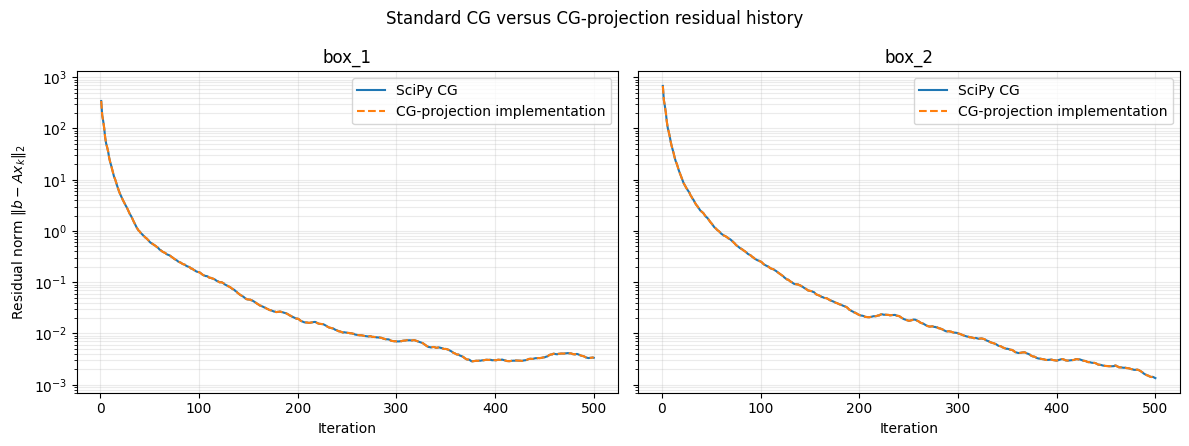

In [6]:
standard_cg_residuals = {}

for box_name, box in boxes.items():
    ell_hat = scale * box[:, 0]
    u_hat = scale * box[:, 1]
    x0 = 0.5 * (ell_hat + u_hat)
    residual_history = []

    def record_residual(xk, history=residual_history):
        history.append(float(np.linalg.norm(b_hat - A_hat @ xk)))

    _, standard_cg_info = cg(
        A_hat,
        b_hat,
        x0=x0,
        rtol=0.0,
        atol=0.0,
        maxiter=cg_projection_iterations,
        callback=record_residual,
    )
    if standard_cg_info not in (0, cg_projection_iterations):
        raise RuntimeError(f"Unexpected SciPy CG info for {box_name}: {standard_cg_info}.")
    standard_cg_residuals[box_name] = np.asarray(residual_history)

fig, axes = plt.subplots(1, len(box_results), figsize=(12, 4.5), sharey=True)
axes = np.atleast_1d(axes)
for ax, (box_name, result) in zip(axes, box_results.items()):
    standard_residuals = standard_cg_residuals[box_name]
    implementation_residuals = result["residual_norms"]
    ax.semilogy(
        np.arange(1, len(standard_residuals) + 1),
        standard_residuals,
        label="SciPy CG",
    )
    ax.semilogy(
        np.arange(1, len(implementation_residuals) + 1),
        implementation_residuals,
        linestyle="--",
        label="CG-projection implementation",
    )
    ax.set_xlabel("Iteration")
    ax.set_title(box_name)
    ax.grid(alpha=0.25, which="both")
    ax.legend()

axes[0].set_ylabel(r"Residual norm $\|b-Ax_k\|_2$")
fig.suptitle("Standard CG versus CG-projection residual history")
fig.tight_layout()
plt.show()


## Controllable animation

The retained diagnostic animation shows coordinate-wise box contraction from the exact Gram-corrected formula. Because the plate system is large, the horizontal axis contains 80 evenly sampled original coordinate indices. The frame slider advances through the diagnostic checkpoints and includes the fixed final iteration $m$.


In [7]:
def display_coordinate_contraction_animation(results, indices, title):
    frame_iterations = np.unique(
        np.concatenate([result["iterations"] for result in results.values()])
    )

    finite_values = np.concatenate([
        result["shrinkage_history"][np.isfinite(result["shrinkage_history"])]
        for result in results.values()
    ])
    y_max = max(1.0, float(np.max(finite_values)) * 1.05) if finite_values.size else 1.0

    fig, ax = plt.subplots(figsize=(9, 4.5))
    lines = {}
    for box_name, result in results.items():
        line, = ax.plot(
            indices,
            np.nan_to_num(result["shrinkage_history"][0]),
            marker="o",
            markersize=3,
            linewidth=1,
            label=box_name,
        )
        lines[box_name] = line

    label = ax.text(0.02, 0.95, "", transform=ax.transAxes, va="top")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set(xlim=(indices[0], indices[-1]), ylim=(0, y_max))
    ax.set_xlabel("Original coordinate index (evenly sampled)")
    ax.set_ylabel("Width reduction (% of original width)")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend()

    def update(frame):
        direction_count = frame_iterations[frame]
        artists = []
        for box_name, result in results.items():
            history_index = np.searchsorted(
                result["iterations"], direction_count, side="right"
            ) - 1
            lines[box_name].set_ydata(
                np.nan_to_num(result["shrinkage_history"][history_index])
            )
            artists.append(lines[box_name])
        label.set_text(f"CG directions {direction_count}")
        return (*artists, label)

    animation = FuncAnimation(
        fig,
        update,
        frames=len(frame_iterations),
        interval=180,
        repeat_delay=1000,
    )
    display(HTML(animation.to_jshtml(fps=5, default_mode="loop")))
    plt.close(fig)
    return animation


### Coordinate contraction

In [8]:
coordinate_contraction_animation = display_coordinate_contraction_animation(
    box_results,
    tracked_indices,
    "Updated plate-system coordinate contraction",
)
